In [1]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

### "trips" adında tablo oluşturulur.

In [2]:
%%duckdb

CREATE OR REPLACE VIEW trips AS
SELECT *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
);

,Count


In [3]:
%%duckdb

SELECT *
FROM trips
LIMIT 3;

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


### İki Nokta Arasındaki Mesafe Haversine Distance Olarak Hesaplanır.

In [10]:
%%duckdb

CREATE OR REPLACE MACRO haversine_km(lat1, lon1, lat2, lon2) AS (
    6371 * 2 * asin(
        sqrt(
            pow(sin(radians(lat2 - lat1) / 2), 2)
            +
            cos(radians(lat1)) * cos(radians(lat2))
            * pow(sin(radians(lon2 - lon1) / 2), 2)
        )
    )
);

,Count


### Regresyon İçin Kullanılacak Inputları ve Aradığımız Değeri İçeren Tablo Oluşturulur.

In [5]:
%%duckdb

CREATE OR REPLACE VIEW regression_input AS
SELECT
    duration_min,

    CAST(strftime(start_at, '%u') AS INTEGER) AS day_of_week,

    CAST(strftime(start_at, '%H') AS INTEGER) AS hour_of_day,

    CAST(strftime(start_at, '%Y') AS INTEGER) - CAST("birth year" AS INTEGER) AS age,

    CASE 
        WHEN gender = 1 THEN 1 
        ELSE 0 
    END AS is_male,
    
    CASE 
        WHEN gender = 2 THEN 1 
        ELSE 0 
    END AS is_female,

    CASE
        WHEN CAST(strftime(start_at, '%u') AS INTEGER) IN (6, 7) THEN 1
        ELSE 0
    END AS weekend_ind,

    CASE
        WHEN usertype = 'Subscriber' THEN 1
        ELSE 0
    END AS is_subscriber,

    haversine_km(
        "start station latitude",
        "start station longitude",
        "end station latitude",
        "end station longitude"
    ) AS distance_km

FROM trips
WHERE duration_min IS NOT NULL
  AND duration_min > 0
  AND duration_min < 24 * 60
  AND start_at IS NOT NULL
  AND stop_at IS NOT NULL
  AND "birth year" IS NOT NULL
  AND "birth year" BETWEEN 1930 AND 2005
  AND gender IS NOT NULL
  AND usertype IS NOT NULL
  AND "start station latitude" IS NOT NULL
  AND "start station longitude" IS NOT NULL
  AND "end station latitude" IS NOT NULL
  AND "end station longitude" IS NOT NULL;

,Count


### Kolay Preprocess için Pandas Dataframe Objesine Dönüştürülür.

In [6]:
import duckdb

df = duckdb.sql("""
SELECT *
FROM regression_input
""").df()

df.head()

,duration_min,day_of_week,hour_of_day,age,is_male,is_female,weekend_ind,is_subscriber,distance_km
0,23,4,0,55,0,1,0,1,3.615820
1,6,4,0,52,1,0,0,1,0.560745
2,6,4,0,41,1,0,0,1,0.918719
3,3,4,0,46,1,0,0,1,0.602053
4,16,4,0,38,1,0,0,1,2.122555


### Checkpoint: Regresyon Girdileri CSV ye Kaydedilir.

In [7]:
df.to_csv("regression_input")

### Dataframe Outlier Çıkarımı Sonrasında X ve y Olacak Şekilde Bölünür.

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("regression_input")
df = df[
    (df["duration_min"] > 0) &
    (df["duration_min"] < 150)
]
y = df["duration_min"]
X = df.drop(columns="duration_min")

### Train Validation Split

In [5]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

### Modelin Eğitimi

In [6]:
model = LinearRegression()
model.fit(X_train_val, y_train_val)

LinearRegression()

### Error Hesabı

In [7]:
y_pred = model.predict(X_test)

errors = {
    "R^2_Score": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "Accuracy_5min": np.mean(np.abs(y_test - y_pred) <= 5),
    "Accuracy_10min": np.mean(np.abs(y_test - y_pred) <= 10)
}

errors

{'R^2_Score': 0.017324864474031476,
 'MAE': np.float64(6.511132869359227),
 'MSE': np.float64(83.59995988375086),
 'RMSE': np.float64(9.143301366779445),
 'Accuracy_5min': np.float64(0.4615981643761818),
 'Accuracy_10min': np.float64(0.8574496045666645)}

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speed_{bike} = x | gender = a)
$$

- Note that $P(speed_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speed_{bike} = x | gender = a)$ modeled

In [1]:
%%duckdb -o gender_1_duration


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
) where gender =1 
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
1,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6
2,384,Fulton St & Waverly Ave,40.683178,-73.965964,399,Lafayette Ave & St James Pl,40.688515,-73.964763,19610,Subscriber,1969.0,1,2015-01-01 00:04:00,2015-01-01 00:07:00,3


### Gerekli Verilerin Hazırlnaması

In [2]:
%%duckdb

CREATE OR REPLACE VIEW trips AS
SELECT *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
);

,Count


In [3]:
%%duckdb

CREATE OR REPLACE MACRO haversine_km(lat1, lon1, lat2, lon2) AS (
    6371 * 2 * asin(
        sqrt(
            pow(sin(radians(lat2 - lat1) / 2), 2)
            +
            cos(radians(lat1)) * cos(radians(lat2))
            * pow(sin(radians(lon2 - lon1) / 2), 2)
        )
    )
);

,Count


In [4]:
%%duckdb

CREATE OR REPLACE VIEW nb_speed_data AS
SELECT
    gender,

    haversine_km(
        "start station latitude",
        "start station longitude",
        "end station latitude",
        "end station longitude"
    ) AS distance_km,

    duration_min,

    haversine_km(
        "start station latitude",
        "start station longitude",
        "end station latitude",
        "end station longitude"
    ) / (duration_min / 60.0) AS speed_kmh

FROM trips
WHERE gender IN (1, 2)
  AND duration_min IS NOT NULL
  AND duration_min > 0
  AND duration_min < 180
  AND "start station latitude" IS NOT NULL
  AND "start station longitude" IS NOT NULL
  AND "end station latitude" IS NOT NULL
  AND "end station longitude" IS NOT NULL;

,Count


In [5]:
%%duckdb

CREATE OR REPLACE VIEW nb_speed_clean AS
SELECT *
FROM nb_speed_data
WHERE speed_kmh > 1
  AND speed_kmh < 40;

,Count


### Verinin pandas a Geçirilip Görselleştirmesi

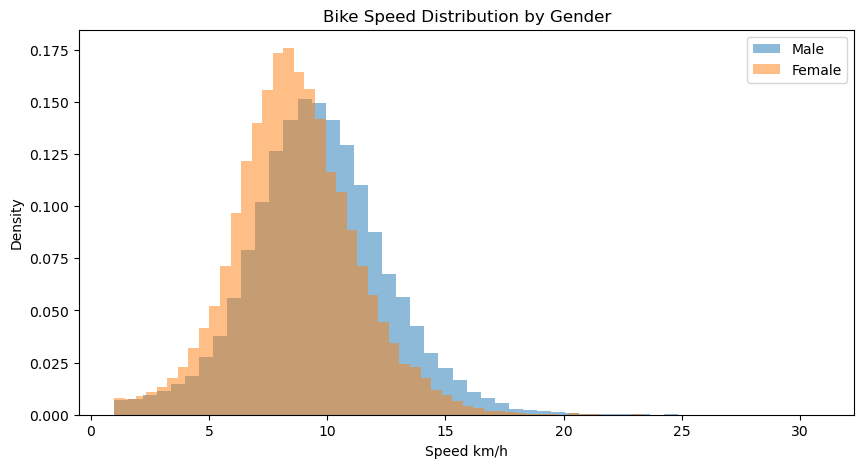

In [6]:
import duckdb
import matplotlib.pyplot as plt

df_vis = duckdb.sql("""
    SELECT gender, speed_kmh
    FROM nb_speed_clean
    USING SAMPLE 100000 ROWS
""").df()

male_speed = df_vis[df_vis["gender"] == 1]["speed_kmh"]
female_speed = df_vis[df_vis["gender"] == 2]["speed_kmh"]

plt.figure(figsize=(10, 5))
plt.hist(male_speed, bins=50, density=True, alpha=0.5, label="Male")
plt.hist(female_speed, bins=50, density=True, alpha=0.5, label="Female")
plt.xlabel("Speed km/h")
plt.ylabel("Density")
plt.title("Bike Speed Distribution by Gender")
plt.legend()
plt.show()

### Gerekli Importlar ve Data Preprocess

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
data = df_vis[["gender", "speed_kmh"]].copy()

data = data[data["gender"].isin([1, 2])]

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

data = data[
    (data["speed_kmh"] > 1) &
    (data["speed_kmh"] < 40)
]

data.head()

,gender,speed_kmh
0,1,8.506019
1,1,10.968039
2,1,4.511624
3,1,9.272038
4,1,10.153035


### Train Val Split

In [12]:
train_df, val_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["gender"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print(train_df["gender"].value_counts(normalize=True))
print(val_df["gender"].value_counts(normalize=True))

Train size: 80000
Validation size: 20000
gender
1    0.760075
2    0.239925
Name: proportion, dtype: float64
gender
1    0.76005
2    0.23995
Name: proportion, dtype: float64


### Prior Mu ve Sigma Hesabı

In [13]:
def train_normal_nb(train_df):
    params = {}

    total_count = len(train_df)

    for gender_value in sorted(train_df["gender"].unique()):
        subset = train_df[train_df["gender"] == gender_value]
        speed = subset["speed_kmh"].values

        params[gender_value] = {
            "prior": len(subset) / total_count,
            "mu": speed.mean(),
            "sigma": speed.std(ddof=1)
        }

    return params

In [14]:
normal_params = train_normal_nb(train_df)

normal_model_df = pd.DataFrame.from_dict(normal_params, orient="index")
normal_model_df.index.name = "gender"
normal_model_df = normal_model_df.reset_index()

normal_model_df

,gender,prior,mu,sigma
0,1,0.760075,9.629199,2.928519
1,2,0.239925,8.616491,2.595426


### PDF Hesabı

In [18]:
def normal_log_pdf(x, mu, sigma):
    sigma = max(sigma, 1e-9)

    return (
        -np.log(sigma)
        -0.5 * np.log(2 * np.pi)
        -0.5 * ((x - mu) / sigma) ** 2
    )

### Model Eğitimi ve Evaluation

In [19]:
def predict_normal_nb_with_probabilities(speed_values, params):
    results = []

    for x in speed_values:
        log_scores = {}
        likelihoods = {}

        for gender_value, p in params.items():
            log_prior = np.log(p["prior"])
            log_likelihood = normal_log_pdf(x, p["mu"], p["sigma"])

            log_scores[gender_value] = log_prior + log_likelihood
            likelihoods[gender_value] = np.exp(log_likelihood)

        # Convert log scores to probabilities
        max_log_score = max(log_scores.values())

        exp_scores = {
            gender_value: np.exp(score - max_log_score)
            for gender_value, score in log_scores.items()
        }

        total_exp_score = sum(exp_scores.values())

        probabilities = {
            gender_value: exp_score / total_exp_score
            for gender_value, exp_score in exp_scores.items()
        }

        predicted_gender = max(probabilities, key=probabilities.get)

        row = {
            "speed_kmh": x,
            "predicted_gender": predicted_gender
        }

        for gender_value in sorted(params.keys()):
            row[f"P(gender={gender_value})"] = params[gender_value]["prior"]
            row[f"P(speed | gender={gender_value})"] = likelihoods[gender_value]
            row[f"P(gender={gender_value} | speed)"] = probabilities[gender_value]

        results.append(row)

    return pd.DataFrame(results)

In [20]:
probability_results = predict_normal_nb_with_probabilities(
    val_df["speed_kmh"].values,
    normal_params
)

probability_results.head(10)

,speed_kmh,predicted_gender,P(gender=1),P(speed | gender=1),P(gender=1 | speed),P(gender=2),P(speed | gender=2),P(gender=2 | speed)
0,11.821283,1,0.760075,0.102943,0.819733,0.239925,0.071716,0.180267
1,13.869891,1,0.760075,0.047745,0.884156,0.239925,0.019818,0.115844
2,20.474853,1,0.760075,0.000143,0.990167,0.239925,0.000005,0.009833
3,5.489371,1,0.760075,0.050157,0.681141,0.239925,0.074383,0.318859
4,8.769870,1,0.760075,0.130486,0.729293,0.239925,0.153442,0.270707
5,11.189472,1,0.760075,0.118201,0.799281,0.239925,0.094036,0.200719
6,15.541874,1,0.760075,0.017746,0.927848,0.239925,0.004372,0.072152
7,7.371921,1,0.760075,0.101216,0.700621,0.239925,0.137016,0.299379
8,7.755165,1,0.760075,0.111004,0.707373,0.239925,0.145474,0.292627
9,9.651153,1,0.760075,0.136223,0.752460,0.239925,0.141969,0.247540


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

y_true = val_df["gender"].astype(int).values
y_pred = probability_results["predicted_gender"].astype(int).values

actual_distribution = pd.Series(y_true).value_counts(normalize=True).sort_index()
predicted_distribution = pd.Series(y_pred).value_counts(normalize=True).sort_index()

distribution_df = pd.DataFrame({
    "Actual Distribution": actual_distribution,
    "Predicted Distribution": predicted_distribution
}).fillna(0)

distribution_df.index.name = "gender"

distribution_df

,Actual Distribution,Predicted Distribution
gender,,
1,0.76005,1.0
2,0.23995,0.0
